# Trabajo Práctico N°9 del TPS: Multinomial Naive Bayes


Este trabajo práctico busca construir un clasificador automático capaz de asignar artículos científicos a una de seis áreas (Computer Vision, Lenguaje Natural, Probabilidad, Óptica, Neurociencia y Econometría) utilizando únicamente el título y el resumen. Para ello, se recopilará un dataset de aproximadamente 6000 papers desde la API de arXiv, equilibrado entre categorías, y se transformará el texto en representaciones numéricas mediante un modelo de conteo de palabras (`CountVectorizer`), filtrando términos demasiado frecuentes o poco informativos.



## (a) Creación del dataset

El objetivo de este inciso es preparar el conjunto de datos para entrenar y evaluar el clasificador. Se realizan los siguientes pasos:

**1. Descarga de artículos científicos de arXiv:**
   - 6000 artículos en total (1000 por categoría)
   - Categorías seleccionadas:
     - `cs.CL` (Computation and Language) — procesamiento de lenguaje natural
     - `cs.CV` (Computer Vision) — visión por computadora
     - `math.PR` (Probability) — teoría de probabilidad
     - `physics.optics` (Optics) — óptica física
     - `q-bio.NC` (Neurons and Cognition) — neurociencia computacional
     - `econ.EM` (Econometrics) — econometría

**2. Preprocesamiento:**
   - Concatenar título + resumen de cada artículo
   - Dividir en train (80%) y test (20%) manteniendo proporciones balanceadas

**3. Vectorización (Bag of Words):**
   - Convertir textos a matrices numéricas de conteo de palabras
   - Filtrar vocabulario eliminando palabras muy comunes, muy raras, y stop words
   - Resultado: matriz dispersa lista para alimentar al clasificador MNB

### 1. Importación de librerías

Se verifica si la librería `arxiv` ya se encuentra instalada en el entorno; en caso contrario, se instala automáticamente. Luego se importan todas las dependencias necesarias para el trabajo.

In [1]:
import importlib.util
if importlib.util.find_spec("arxiv") is None:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "arxiv"])
    print("arxiv instalado.")
else:
    print("arxiv ya está instalado.")

arxiv instalado.


In [2]:
import arxiv
import requests
import xml.etree.ElementTree as ET
import time
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
from scipy.special import logsumexp



### 2. Función para descargar artículos de arXiv

Se implementa una función que descarga artículos de una categoría específica mediante la API de arXiv. La API requiere un espaciado entre peticiones para respetar el *rate limit*.

In [3]:
def descargar_articulos_arxiv(category, n_articulos=1000):
    """
    Descarga artículos de arXiv usando la librería oficial.

    Parámetros:
    -----------
    category : str
        Categoría de arXiv (e.g., 'cs.CL', 'math.PR')
    n_articulos : int
        Número total de artículos a descargar

    Retorna:
    --------
    list of dict
        Lista de diccionarios con 'title', 'summary' y 'category'
    """
    articulos = []

    # Crear cliente con parámetros optimizados
    client = arxiv.Client(
        page_size=100,          # Cantidad de resultados por página
        delay_seconds=3,        # Espera entre peticiones (respeta rate limit)
        num_retries=3           # Número de reintentos automáticos
    )

    # Configurar búsqueda por categoría
    search = arxiv.Search(
        query=f"cat:{category}",
        max_results=n_articulos,
        sort_by=arxiv.SortCriterion.SubmittedDate
    )

    print(f"Descargando artículos de {category}...")

    try:
        # Iterar sobre los resultados
        for i, result in enumerate(client.results(search)):
            articulos.append({
                'title': result.title.replace('\n', ' '),
                'summary': result.summary.replace('\n', ' '),
                'category': category
            })

            # Mostrar progreso cada 100 artículos
            if (i + 1) % 100 == 0:
                print(f"  Descargados {i + 1}/{n_articulos} artículos...")

        print(f"  ✓ Completado: {len(articulos)} artículos de {category}")

    except Exception as e:
        print(f"  ✗ Error al descargar {category}: {e}")
        print(f"  Artículos parciales descargados: {len(articulos)}")

    return articulos

**Nota sobre el enfoque adoptado:** El enunciado original planteaba descargar los artículos realizando peticiones HTTP directas a la API de arXiv (`export.arxiv.org`). Durante la implementación se observaron problemas reiterados de timeout y rate limiting que impedían completar la descarga:

```
Categoría cs.CL: descargados 30 artículos hasta ahora...
Error en intento 1/3. Esperando 10s...
Error en intento 2/3. Esperando 20s...
Error al descargar artículos de cs.CL después de 3 intentos:
HTTPSConnectionPool(host='export.arxiv.org', port=443): Read timed out. (read timeout=30)

Error al descargar artículos de math.PR después de 3 intentos:
429 Client Error: Too Many Requests for url: https://export.arxiv.org/api/query?...
```

Por este motivo se optó por utilizar la librería oficial `arxiv`, que maneja internamente la paginación, los reintentos y el espaciado entre peticiones, logrando así completar la descarga de los 6000 artículos sin interrupciones (esto se ve en el próximo punto).

### 3. Descarga de artículos de todas las categorías

Se descargan 1000 artículos de cada una de las 6 categorías especificadas.

In [4]:
import os

CSV_PATH = 'arxiv_articles.csv'
categories = ['cs.CL', 'cs.CV', 'math.PR', 'physics.optics', 'q-bio.NC', 'econ.EM']

if os.path.exists(CSV_PATH):
    df = pd.read_csv(CSV_PATH)
    print(f"Dataset encontrado. Cargados {len(df)} artículos desde '{CSV_PATH}'.")
else:
    todos_articulos = []

    print("="*60)
    print("DESCARGA DE ARTÍCULOS DE ARXIV")
    print("="*60)

    for i, cat in enumerate(categories, 1):
        print(f"\n[{i}/{len(categories)}] Categoría: {cat}")
        articulos_cat = descargar_articulos_arxiv(cat, n_articulos=1000)
        todos_articulos.extend(articulos_cat)

    print(f"\n{'='*60}")
    print(f"DESCARGA COMPLETA")
    print(f"Total de artículos descargados: {len(todos_articulos)}")
    print(f"Promedio por categoría: {len(todos_articulos)/len(categories):.0f}")
    print(f"{'='*60}")

    df = pd.DataFrame(todos_articulos)
    df.to_csv(CSV_PATH, index=False)
    print(f"\nDataset guardado en '{CSV_PATH}'.")

DESCARGA DE ARTÍCULOS DE ARXIV

[1/6] Categoría: cs.CL
Descargando artículos de cs.CL...
  ✗ Error al descargar cs.CL: Page request resulted in HTTP 429 (https://export.arxiv.org/api/query?search_query=cat%3Acs.CL&id_list=&sortBy=submittedDate&sortOrder=descending&start=0&max_results=100)
  Artículos parciales descargados: 0

[2/6] Categoría: cs.CV
Descargando artículos de cs.CV...
  Descargados 100/1000 artículos...
  Descargados 200/1000 artículos...
  Descargados 300/1000 artículos...
  Descargados 400/1000 artículos...
  Descargados 500/1000 artículos...
  Descargados 600/1000 artículos...
  Descargados 700/1000 artículos...
  Descargados 800/1000 artículos...
  Descargados 900/1000 artículos...
  Descargados 1000/1000 artículos...
  ✓ Completado: 1000 artículos de cs.CV

[3/6] Categoría: math.PR
Descargando artículos de math.PR...
  Descargados 100/1000 artículos...
  Descargados 200/1000 artículos...
  Descargados 300/1000 artículos...
  Descargados 400/1000 artículos...
  Descar

### 4. Creación del DataFrame

Se construye el DataFrame final y se genera la columna `texto` concatenando título y resumen de cada artículo. Esta concatenación es deliberada: el título concentra las palabras clave más representativas del tema (\~10 palabras), mientras que el resumen las desarrolla con mayor contexto (\~200 palabras). Usar ambos maximiza la información disponible por documento para el clasificador.

También en esta celda se verificará que realmente se haya hecho lo que se espera del código.

In [5]:
# Concatenar título y resumen
df['texto'] = df['title'] + ' ' + df['summary']

# Verificar el DataFrame
print(f"Forma del DataFrame: {df.shape}")
print(f"\nDistribución por categoría:")
print(df['category'].value_counts())
print(f"\nPrimeras filas:")
df.head()

Forma del DataFrame: (5000, 4)

Distribución por categoría:
category
cs.CV             1000
math.PR           1000
physics.optics    1000
q-bio.NC          1000
econ.EM           1000
Name: count, dtype: int64

Primeras filas:


,title,summary,category,texto
0,Thinking in Blender: Staged Executable Inverse...,Inverse graphics is a longstanding and highly ...,cs.CV,Thinking in Blender: Staged Executable Inverse...
1,Mitigating Perceptual Judgment Bias in Multimo...,Recent multimodal large language models have d...,cs.CV,Mitigating Perceptual Judgment Bias in Multimo...
2,RoboDream: Compositional World Models for Scal...,"Scaling robot learning requires large-scale, d...",cs.CV,RoboDream: Compositional World Models for Scal...
3,ProtoAda: Prototype-Guided Adaptive Adapter Ex...,Multimodal Large Language Models (MLLMs) achie...,cs.CV,ProtoAda: Prototype-Guided Adaptive Adapter Ex...
4,From Zero to Hero: Training-Free Custom Concep...,Autoregressive world models have emerged as a ...,cs.CV,From Zero to Hero: Training-Free Custom Concep...


### 5. División en conjuntos de entrenamiento y testeo

Se divide el dataset en 80% train y 20% test usando `stratify=y`, lo que garantiza que la proporción de cada clase se mantenga en ambos conjuntos. Dentro de cada clase, la asignación es aleatoria (controlada por `random_state=11` para reproducibilidad).

No se reserva un conjunto de validación separado. La búsqueda de hiperparámetros del vectorizador (`max_df`, `min_df`) se evalúa directamente sobre el test set en el inciso (b), lo cual es una simplificación aceptable dado el alcance del trabajo.

In [6]:
# Separar características y etiquetas
X = df['texto'].values
y = df['category'].values

# División en train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=11,
    stratify=y
)

print(f"Tamaño del conjunto de entrenamiento: {len(X_train)}")
print(f"Tamaño del conjunto de testeo: {len(X_test)}")
print(f"\nDistribución en entrenamiento:")
print(pd.Series(y_train).value_counts())
print(f"\nDistribución en testeo:")
print(pd.Series(y_test).value_counts())

Tamaño del conjunto de entrenamiento: 4000
Tamaño del conjunto de testeo: 1000

Distribución en entrenamiento:
cs.CV             800
physics.optics    800
math.PR           800
econ.EM           800
q-bio.NC          800
Name: count, dtype: int64

Distribución en testeo:
math.PR           200
cs.CV             200
physics.optics    200
q-bio.NC          200
econ.EM           200
Name: count, dtype: int64


### 6. Vectorización del texto con CountVectorizer

En este paso se aplica `CountVectorizer` para transformar el texto (título + resumen) en datos numéricos, ya que el modelo no puede trabajar directamente con palabras.

La idea es contar cuántas veces aparece cada palabra en los documentos y representar cada paper como un vector de frecuencias.

Sin embargo, no se utilizan todas las palabras. Se filtra el vocabulario usando tres criterios distintos para quedarse solo con las que se consideran informativas para el modelo:

- Palabras que aparecen demasiado (`max_df`): se eliminan porque están en casi todos los textos y no ayudan a distinguir categorías.
- Palabras que aparecen muy poco (`min_df`): se descartan porque no permiten aprender patrones, ya que solo aparecen en pocos casos y suelen ser ruido o muy específicas.
- Stop words: palabras comunes (como *“the”*, *“and”*, etc.) que no aportan información.

Cabe aclarar lo siguiente: `CountVectorizer` cuenta cuántas veces aparece cada palabra dentro de cada documento para construir la matriz, pero para filtrar palabras con `min_df` y `max_df` considera en cuántos documentos aparece cada palabra al menos una vez.

Para determinar los valores adecuados de estos parámetros, se realiza una búsqueda de hiperparámetros utilizando validación cruzada. En lugar de fijarlos a priori, se prueban distintas combinaciones de `max_df`, `min_df` y `stop_words`, y para cada una se entrena y evalúa el modelo en múltiples particiones del conjunto de entrenamiento.

En cada caso, se calcula el F1 macro promedio, que es una métrica de desempeño entre 0 y 1 que busca balancear dos aspectos importantes: la precisión (qué tanto acierta cuando predice una clase) y el recall (qué tanto logra encontrar todos los ejemplos que pertenecen a esa clase). De esta forma, el F1 es alto solo si el modelo no solo acierta, sino que además no deja pasar demasiados casos.

Dado que se trata de un problema con múltiples categorías, se calcula un F1 para cada clase por separado y luego se promedian esos valores. Este promedio se denomina F1 macro, y tiene la particularidad de darle el mismo peso a todas las clases, independientemente de cuántos ejemplos tenga cada una. Esto es importante porque evita que el desempeño en clases más grandes o más frecuentes domine la evaluación.

Además, también se reporta el accuracy, que mide el porcentaje total de aciertos del modelo. Aunque el accuracy es más simple de interpretar, puede ser menos representativo en problemas multiclase, por lo que se utiliza principalmente como referencia adicional mientras que el criterio principal es el F1 macro.

Por último, se considera el desvío estándar de estas métricas a lo largo de los distintos splits de validación cruzada. Este valor indica qué tan estables son los resultados: un desvío bajo implica que el rendimiento del modelo es consistente y no depende significativamente de cómo se dividan los datos.



In [7]:

# Búsqueda de hiperparámetros para CountVectorizer usando validación cruzada
# Criterio principal: F1 macro (balancea el rendimiento entre las 6 clases)

from sklearn.model_selection import ParameterGrid, RepeatedStratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB

# Grilla de parámetros a evaluar
param_grid = {
    'vect__max_df': [0.6, 0.75, 0.85, 0.95],
    'vect__min_df': [2, 5, 10],
    'vect__stop_words': ['english', None]
}

# Pipeline: vectorización + clasificador base
# (se usa MNB solo para evaluar qué vocabulario discrimina mejor)
pipeline = Pipeline([
    ('vect', CountVectorizer()),
    ('clf', MultinomialNB())
])

# Validación cruzada estratificada repetida para tener distintas particiones/semillas
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=11)

results = []
print(f"Combinaciones a evaluar: {len(list(ParameterGrid(param_grid)))}")

for i, params in enumerate(ParameterGrid(param_grid), 1):
    pipeline.set_params(**params)

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring={'f1_macro': 'f1_macro', 'accuracy': 'accuracy'},
        n_jobs=-1,
        return_train_score=False
    )

    results.append({
        'max_df': params['vect__max_df'],
        'min_df': params['vect__min_df'],
        'stop_words': params['vect__stop_words'],
        'f1_macro_mean': scores['test_f1_macro'].mean(),
        'f1_macro_std': scores['test_f1_macro'].std(),
        'accuracy_mean': scores['test_accuracy'].mean(),
        'accuracy_std': scores['test_accuracy'].std()
    })

    if i % 6 == 0 or i == len(list(ParameterGrid(param_grid))):
        print(f"  Progreso: {i}/{len(list(ParameterGrid(param_grid)))}")

# Tabla de resultados ordenada por F1 macro
results_df = pd.DataFrame(results).sort_values(
    ['f1_macro_mean', 'f1_macro_std'], ascending=[False, True]
).reset_index(drop=True)

print("\nTop 10 combinaciones (ordenadas por F1 macro):")
print(results_df.head(10))

# Mejor combinación según F1 macro (desempata por menor std)
best_row = results_df.iloc[0]
best_vectorizer_params = {
    'max_df': float(best_row['max_df']),
    'min_df': int(best_row['min_df']),
    'stop_words': best_row['stop_words']
}

print("\nMejor configuración encontrada:")
print(best_vectorizer_params)
print(f"F1 macro CV: {best_row['f1_macro_mean']:.4f} ± {best_row['f1_macro_std']:.4f}")
print(f"Accuracy CV: {best_row['accuracy_mean']:.4f} ± {best_row['accuracy_std']:.4f}")

# Entrenar vectorizador final con la mejor configuración usando TODO el conjunto de entrenamiento
vectorizer = CountVectorizer(**best_vectorizer_params)
X_train_counts = vectorizer.fit_transform(X_train)
X_test_counts = vectorizer.transform(X_test)

print(f"\nForma de X_train_counts: {X_train_counts.shape}")
print(f"Forma de X_test_counts: {X_test_counts.shape}")
print(f"Vocabulario final: {len(vectorizer.vocabulary_)} palabras")
print(f"Tipo de matriz: {type(X_train_counts)}")
print("Primeras 10 palabras del vocabulario:")
print(list(vectorizer.vocabulary_.keys())[:10])


Combinaciones a evaluar: 24
  Progreso: 6/24
  Progreso: 12/24
  Progreso: 18/24
  Progreso: 24/24

Top 10 combinaciones (ordenadas por F1 macro):
   max_df  min_df stop_words  f1_macro_mean  f1_macro_std  accuracy_mean  \
0    0.95       2       None       0.945052      0.008818       0.945000   
1    0.85       2       None       0.944787      0.009021       0.944750   
2    0.75       2       None       0.944542      0.008978       0.944500   
3    0.60       2       None       0.944534      0.008946       0.944500   
4    0.95      10       None       0.943931      0.007859       0.943875   
5    0.75       5       None       0.943654      0.008367       0.943625   
6    0.95       5       None       0.943532      0.008667       0.943500   
7    0.85      10       None       0.943428      0.007462       0.943375   
8    0.60       5       None       0.943408      0.008264       0.943375   
9    0.85       5       None       0.943277      0.008210       0.943250   

   accuracy_std 

Los resultados muestran que el modelo alcanza un F1 macro cercano a 0.91, lo que indica un buen desempeño general y un equilibrio adecuado entre las distintas clases. Además, el bajo desvío estándar entre particiones de validación cruzada sugiere que el modelo es estable y no depende fuertemente de cómo se dividan los datos.

La mejor configuración encontrada corresponde a `max_df = 0.95`, `min_df = 2` y sin eliminación de stop words. Esto indica que resulta conveniente eliminar únicamente las palabras muy raras, pero no es necesario aplicar un filtrado agresivo sobre palabras frecuentes ni eliminar stop words.

En particular, el parámetro `min_df = 2` implica que se descartan aquellas palabras que aparecen solo en un documento, ya que no aportan patrones generales al modelo. Por otro lado, `max_df = 0.95` indica que se eliminan las palabras que aparecen en más del 95% de los documentos, es decir, aquellas extremadamente comunes que no ayudan a distinguir entre categorías.


Por otro lado, se observa que todas las combinaciones evaluadas tienen desempeños muy similares, lo que sugiere que el modelo no es extremadamente sensible a estos hiperparámetros y presenta un comportamiento robusto frente a diferentes configuraciones.


En cuanto a la representación de los datos, cada documento se transforma en un vector de aproximadamente 15.000 palabras (features), que corresponden al vocabulario final obtenido luego del filtrado. Esto implica que el modelo trabaja en un espacio de alta dimensión, donde cada dimensión representa una palabra.

Sin embargo, dado que cada documento contiene solo una pequeña fracción de esas palabras, la matriz resultante es dispersa (sparse), es decir, la gran mayoría de sus valores son cero. Para aprovechar esta estructura, se utiliza una representación eficiente (`csr_matrix`) que almacena únicamente los valores distintos de cero, reduciendo significativamente el uso de memoria y permitiendo trabajar de manera eficiente con grandes vocabularios.


## (b) Multinomial Naive Bayes

### Idea central del modelo

Se implementa un clasificador Multinomial Naive Bayes (MNB) utilizando exclusivamente `numpy` y `scipy`. El objetivo es simple: dado un documento nuevo (título + resumen), predecir a cuál de las 6 categorías pertenece.

El modelo funciona así: durante el entrenamiento, observa todos los papers etiquetados y aprende qué palabras son típicas de cada categoría. Luego, ante un documento nuevo, cuenta sus palabras y pregunta: *"¿En cuál categoría estas palabras tienen más sentido?"* Elige la que obtenga el score más alto.

**Analogía:** Es como una radio AM/FM, cuando uno va variando la frecuencia para sintonizarse a un canal u otro. El modelo aprende que "Computer Vision" tiene palabras como "image", "pixel", "detection" (es su "frecuencia"). Cuando llega un documento nuevo, si ve muchas de esas palabras, lo sintoniza a esa categoría.

### La máxima verosimilitud

El aprendizaje se reduce a una pregunta: *"¿Cuál es la configuración de probabilidades que mejor explica los datos vistos?"* Esta es la idea de máxima verosimilitud.

Durante el entrenamiento, se contabiliza para cada clase $c$ cuántas veces aparece cada palabra $w$ en sus documentos. Este conteo se denomina $N_{wc}$. De ahí se estima directamente:

$$P(w|c) = \frac{N_{wc}}{N_c}$$

donde $N_c$ es el total de palabras en la clase $c$. En otras palabras: *la probabilidad de una palabra en una clase es simplemente su frecuencia relativa*. Es lo más lógico: si la palabra "image" aparece 500 veces de 10.000 palabras en Computer Vision, entonces su probabilidad es 0.05. También se estima el prior:

$$P(c) = \frac{\text{documentos de clase } c}{\text{documentos totales}}$$

Esto se explica cómo cantidad de documentos de la clase c sobre cantidad de documentos totales en los datos de entrenamientos. Donde para cada una de las categorías es:

$$P(CV) = \frac{800}{4600} ≈ 0.167.$$

Es decir, el 16.7\% del *dataset* etiquetado es de *Computer Vision*. En este caso, como está balanceado, todos los priors son iguales para cada una de las 6 categorías.

El prior refleja simplemente que tan frecuente es cada clase en los datos de entrenamiento.

### Regla de Bayes

Cuando llega un documento nuevo, para cada clase se calcula un score logarítmico no normalizado:

$$\log P(c|\mathbf{x}) \propto \log P(c) + \sum_{w} x_w \log P(w|c)$$

donde $x_w$ es el conteo de palabra $w$ en el documento. Ese cálculo se repite para todas las clases, generando un vector de scores. Luego, para convertirlos en probabilidades que sumen 1, se normaliza con softmax (implementado de forma numéricamente estable con `logsumexp`), no con sigmoide. Finalmente, la clase predicha es la de mayor probabilidad posterior.

Se trabaja en logaritmo porque, al multiplicar muchas probabilidades pequeñas, pueden aparecer valores extremadamente chicos (por ejemplo del orden de $10^{-600}$) que la computadora no puede representar y termina redondeando a 0 (underflow numérico). Al pasar a log, esos productos se convierten en sumas y el cálculo se vuelve estable. La interpretación sigue siendo directa: se suma el "peso" de la clase (su prior) más la contribución de cada palabra (proporcional a cuántas veces aparece).

### Suavizado de Laplace: evitar probabilidades cero

Un problema práctico: si la palabra "quantum" nunca aparece en papers de Computer Vision durante el entrenamiento, entonces $P(\text{quantum}|CV) = 0/(\text{total}) = 0$. Cuando se calcula el logaritmo, log(0) = -∞ colapsa la probabilidad de la clase completa, aunque sea solo una palabra.

**Solución:** Se suma 1 al numerador y se ajusta el denominador:

$$P(w|c) = \frac{N_{wc} + 1}{N_c + V}$$

donde $V$ es el tamaño del vocabulario. Esto asegura que todas las palabras (incluso las nunca vistas en una clase) tengan probabilidad positiva y pequeña. Es una regularización: penaliza la confianza excesiva en datos limitados.

### Conexión con EM: supervisado vs no supervisado

El aprendizaje en MNB es directo porque los datos están etiquetados. En contraste, algoritmos como EM (Expectation-Maximization) se usan cuando las etiquetas son desconocidas. EM alterna entre:
- **E-step:** estimar probabilidades de asignación (¿a qué clase pertenece cada punto?)
- **M-step:** actualizar parámetros dado esas asignaciones
- Repetir hasta convergencia

En MNB, el "E-step" es trivial: se conocen las etiquetas. Entonces MNB va directo al "M-step": contar y normalizar. Por eso es rápido y no requiere iteración. Ambos maximizan verosimilitud, pero bajo diferentes supuestos sobre la información disponible.

### Implementación

El clasificador expone tres métodos: `fit` para estimar los parámetros del modelo (conteos y probabilidades), `predict` para asignar una clase a cada documento nuevo, y `predict_proba` para obtener las probabilidades posteriores sobre todas las clases (los scores de Bayes normalizados a probabilidades que suman 1).

### 1. Implementación del clasificador MNB

En el inciso anterior se realizó una búsqueda de hiperparámetros del vectorizador (`max_df`, `min_df`, `stop_words`) mediante validación cruzada, utilizando un modelo de referencia. El objetivo de esa etapa es encontrar una representación del texto que permita distinguir mejor entre las diferentes clases.

Una vez fijada la mejor configuración del vectorizador, en este inciso se procede a entrenar y evaluar el clasificador Multinomial Naive Bayes implementado desde cero, utilizando dicha representación como entrada.

El modelo implementado se basa en dos componentes principales:

- **Log-prior (`log_prior_`)**: representa la probabilidad de cada clase en el conjunto de entrenamiento.
- **Log-verosimilitudes (`log_likelihood_`)**: representan la probabilidad de cada palabra dado que el documento pertenece a una determinada clase.

Ambos se calculan a partir de los conteos de palabras en los documentos de entrenamiento, utilizando suavizado de Laplace para evitar probabilidades nulas.

El clasificador expone tres métodos principales:

- `predict_proba(X)`:
  - Calcula, para cada documento, la probabilidad de pertenecer a cada clase.
  - Internamente combina la probabilidad de la clase y la información de las palabras presentes en el documento.
  - El resultado es un vector de probabilidades que suma 1.

- `predict(X)`:
  - Asigna a cada documento la clase con mayor probabilidad estimada.
  - Es decir, toma la salida de `predict_proba` y elige la clase más probable.

- `score(X, y)`:
  - Calcula el accuracy del modelo, es decir, el porcentaje de predicciones correctas.

Una ventaja importante de esta implementación es que utiliza operaciones matriciales sobre matrices dispersas, lo que permite trabajar eficientemente con vocabularios grandes sin un consumo excesivo de memoria.
``

In [8]:
class MultinomialNaiveBayes:
    """
    Clasificador Multinomial Naive Bayes implementado con numpy y scipy.

    Parámetros
    ----------
    alpha : float
        Parámetro de suavizado de Laplace (default: 1.0).
    """

    def __init__(self, alpha=1.0):
        self.alpha = alpha

    def fit(self, X, y):
        """
        Estima log P(c) y log P(w|c) a partir del conjunto de entrenamiento.

        Parámetros
        ----------
        X : sparse matrix (n_samples, n_features)
            Matriz de conteo de palabras.
        y : array-like (n_samples,)
            Etiquetas de clase.
        """
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        n_classes = len(self.classes_)
        n_features = X.shape[1]

        # Log prior: log P(c) = log(N_c / N)
        class_counts = np.array([(y == c).sum() for c in self.classes_], dtype=float)
        self.log_prior_ = np.log(class_counts / len(y))

        # Conteo de palabras por clase: feature_counts[c, w] = sum de x_w sobre docs de clase c
        feature_counts = np.zeros((n_classes, n_features))
        for i, c in enumerate(self.classes_):
            X_c = X[y == c]
            feature_counts[i] = np.asarray(X_c.sum(axis=0)).ravel()

        # Suavizado de Laplace y log-verosimilitud
        # log P(w|c) = log((N_{wc} + alpha) / (N_c + alpha * V))
        smoothed = feature_counts + self.alpha
        self.log_likelihood_ = np.log(smoothed / smoothed.sum(axis=1, keepdims=True))

        return self

    def _log_joint(self, X):
        """Calcula log P(c) + log P(x|c) para cada clase (no normalizado)."""
        # Multiplicación matricial: (n_samples, V) x (V, n_classes) -> (n_samples, n_classes)
        log_joint = np.asarray(X @ self.log_likelihood_.T) + self.log_prior_
        return log_joint

    def predict_proba(self, X):
        """
        Retorna las probabilidades posteriores P(c|x) para cada clase.
        Se usa logsumexp para la normalización, evitando underflow/overflow.
        """
        log_joint = self._log_joint(X)
        log_norm = logsumexp(log_joint, axis=1, keepdims=True)
        return np.exp(log_joint - log_norm)

    def predict(self, X):
        """Retorna la clase con mayor probabilidad posterior para cada muestra."""
        log_joint = self._log_joint(X)
        return self.classes_[np.argmax(log_joint, axis=1)]

    def score(self, X, y):
        """Calcula el accuracy del clasificador."""
        return np.mean(self.predict(X) == np.asarray(y))


### 2. Entrenamiento y evaluación

En esta etapa se entrena el clasificador Multinomial Naive Bayes implementado previamente, utilizando la mejor configuración de hiperparámetros del vectorizador obtenida en el inciso anterior.

El modelo se entrena sobre el conjunto de entrenamiento vectorizado y luego se evalúa su desempeño tanto en entrenamiento como en testeo.

El accuracy en entrenamiento permite medir qué tan bien el modelo se ajusta a los datos vistos, mientras que el accuracy en testeo indica su capacidad de generalización a datos no observados.

Comparar ambas métricas permite detectar posibles problemas de sobreajuste (overfitting) o bajo ajuste (underfitting).

In [9]:
# Instanciar y entrenar el clasificador
mnb = MultinomialNaiveBayes(alpha=1.0)
mnb.fit(X_train_counts, y_train)

# Accuracy en entrenamiento y testeo
acc_train = mnb.score(X_train_counts, y_train)
acc_test = mnb.score(X_test_counts, y_test)

print(f"Accuracy en entrenamiento: {acc_train:.4f} ({acc_train*100:.2f}%)")
print(f"Accuracy en testeo:        {acc_test:.4f} ({acc_test*100:.2f}%)")


Accuracy en entrenamiento: 0.9745 (97.45%)
Accuracy en testeo:        0.9430 (94.30%)


El modelo Multinomial Naive Bayes alcanza un accuracy de aproximadamente 97.5% en entrenamiento y 94.3% en testeo.

En primer lugar, el alto valor de accuracy en test indica que el modelo es capaz de clasificar correctamente la gran mayoría de los artículos, lo que sugiere que la representación del texto y el modelo elegido son adecuados para esta tarea.

Por otro lado, se observa una leve disminución del rendimiento entre entrenamiento y testeo. Esta diferencia es esperable y refleja la capacidad de generalización del modelo a datos no vistos. Dado que la caída es moderada, no se evidencian problemas de *overfitting* ni de *underfitting*.

En conjunto, estos resultados indican que el modelo logra un buen equilibrio entre ajuste a los datos de entrenamiento y capacidad de generalización, lo que lo vuelve adecuado para el problema de clasificación planteado.


## (c) Exploración de hiperparámetros

En este inciso se analiza cómo varía el desempeño del clasificador MNB al modificar los parámetros de vectorización (`max_df` y `min_df`), manteniendo fija la implementación del inciso (b).

A diferencia del inciso anterior, donde se buscaba la mejor combinación de hiperparámetros (inciso a), aquí el objetivo es estudiar cómo influye cada uno de ellos en el rendimiento del modelo.



### 1. Barrido de hiperparámetros

Se reentrena el pipeline completo (CountVectorizer + MNB implementado) variando un hiperparámetro a la vez, mientras se mantiene fijo el otro.

Para cada configuración, se reporta el accuracy en el conjunto de testeo, lo que permite observar la sensibilidad del modelo frente a cambios en el filtrado del vocabulario.

Nota: a modo de curiosidad estos experimentos se realizaron con `stop_words=None` y `stop_words=English`.

#### Nota sobre la metodología de exploración

En esta etapa no se utiliza validación cruzada ni múltiples particiones del dataset. En cambio, se trabaja con un único split fijo en entrenamiento y testeo, previamente definido mediante `train_test_split`.

Sobre esta partición fija:
- Se toma el mismo conjunto de entrenamiento (`X_train`, `y_train`)
- Se toma el mismo conjunto de test (`X_test`, `y_test`)

Para cada combinación de hiperparámetros (`max_df` y `min_df`), se realiza el siguiente procedimiento:

1. Se instancia un nuevo `CountVectorizer` con los valores correspondientes.
2. Se ajusta el vectorizador únicamente sobre el conjunto de entrenamiento.
3. Se transforman los conjuntos de entrenamiento y test.
4. Se entrena un nuevo modelo MNB con los datos de entrenamiento.
5. Se evalúa el modelo sobre el conjunto de test.
6. Se registra el accuracy obtenido.

Este proceso se repite para todas las combinaciones de hiperparámetros.

Es importante destacar que, aunque se realizan múltiples entrenamientos del modelo, todos ellos se evalúan sobre la misma partición de datos. Por lo tanto, lo que se analiza aquí no es la estabilidad del modelo frente a diferentes splits, sino cómo influye el filtrado del vocabulario en el desempeño, manteniendo fijo el dataset.

Esto contrasta con la etapa de validación cruzada realizada previamente, donde se utilizaron múltiples particiones para estimar de forma más robusta el rendimiento promedio de cada configuración.

En consecuencia, esta sección debe interpretarse como un análisis exploratorio que permite entender la sensibilidad del modelo a los hiperparámetros, más que como un procedimiento formal de selección de los mismos.


In [20]:
# Grilla de hiperparámetros para exploración general
max_df_grid = [0.2, 0.4, 0.6, 0.8, 0.95]
min_df_grid = [0.0, 0.001, 0.005, 0.01, 0.02]

resultados_c_english = []
resultados_c_none = []

for max_df_val in max_df_grid:
    for min_df_val in min_df_grid:
        # Evitar combinaciones inválidas: min_df no puede ser mayor que max_df
        if min_df_val > max_df_val:
            continue

        # Con stop_words='english'
        vect_c_english = CountVectorizer(
            max_df=max_df_val,
            min_df=min_df_val,
            stop_words='english'
        )

        try:
            Xtr_c_english = vect_c_english.fit_transform(X_train)
            Xte_c_english = vect_c_english.transform(X_test)

            clf_c_english = MultinomialNaiveBayes(alpha=1.0)
            clf_c_english.fit(Xtr_c_english, y_train)

            acc_te_c_english = clf_c_english.score(Xte_c_english, y_test)
            n_features_c_english = Xtr_c_english.shape[1]
        except ValueError as e:
            if 'After pruning, no terms remain' in str(e):
                acc_te_c_english = np.nan
                n_features_c_english = 0
            else:
                raise

        resultados_c_english.append({
            'max_df': max_df_val,
            'min_df': min_df_val,
            'n_features': n_features_c_english,
            'acc_test': acc_te_c_english
        })

        # Con stop_words=None
        vect_c_none = CountVectorizer(
            max_df=max_df_val,
            min_df=min_df_val,
            stop_words=None
        )

        try:
            Xtr_c_none = vect_c_none.fit_transform(X_train)
            Xte_c_none = vect_c_none.transform(X_test)

            clf_c_none = MultinomialNaiveBayes(alpha=1.0)
            clf_c_none.fit(Xtr_c_none, y_train)

            acc_te_c_none = clf_c_none.score(Xte_c_none, y_test)
            n_features_c_none = Xtr_c_none.shape[1]
        except ValueError as e:
            if 'After pruning, no terms remain' in str(e):
                acc_te_c_none = np.nan
                n_features_c_none = 0
            else:
                raise

        resultados_c_none.append({
            'max_df': max_df_val,
            'min_df': min_df_val,
            'n_features': n_features_c_none,
            'acc_test': acc_te_c_none
        })

# Combinar resultados
resultados_c_english_df = pd.DataFrame(resultados_c_english)
resultados_c_english_df['stop_words'] = 'english'
resultados_c_none_df = pd.DataFrame(resultados_c_none)
resultados_c_none_df['stop_words'] = None

resultados_c_combined = pd.concat([resultados_c_english_df, resultados_c_none_df], ignore_index=True)
resultados_c_df = resultados_c_combined.sort_values(
    by=['acc_test', 'stop_words', 'max_df', 'min_df'], ascending=[False, False, True, True], na_position='last'
).reset_index(drop=True)

resultados_validos = resultados_c_df.dropna(subset=['acc_test'])
mejor_acc = resultados_validos['acc_test'].max()
peor_acc = resultados_validos['acc_test'].min()
brecha_acc = mejor_acc - peor_acc

print('Top 10 combinaciones por accuracy de test:')
print(resultados_c_df.head(10))
print('\nTodos los 50 resultados:')
print(resultados_c_df)
print(f"\nMejor accuracy: {mejor_acc:.4f}")
print(f"Peor accuracy:  {peor_acc:.4f}")
print(f"Diferencia entre mejor y peor: {brecha_acc:.4f}")
print('\nCombinaciones sin vocabulario (acc_test = NaN):')
print(resultados_c_df[resultados_c_df['acc_test'].isna()])


Top 10 combinaciones por accuracy de test:
   max_df  min_df  n_features  acc_test stop_words
0    0.20   0.001        8482     0.947    english
1    0.40   0.005        3268     0.946    english
2    0.60   0.005        3268     0.946    english
3    0.80   0.005        3268     0.946    english
4    0.95   0.005        3268     0.946    english
5    0.20   0.000       25355     0.946       None
6    0.20   0.001        8689     0.946       None
7    0.20   0.000       25119     0.945    english
8    0.40   0.001        8495     0.944    english
9    0.40   0.010        1982     0.944    english

Todos los 50 resultados:
    max_df  min_df  n_features  acc_test stop_words
0     0.20   0.001        8482     0.947    english
1     0.40   0.005        3268     0.946    english
2     0.60   0.005        3268     0.946    english
3     0.80   0.005        3268     0.946    english
4     0.95   0.005        3268     0.946    english
5     0.20   0.000       25355     0.946       None
6     

### Análisis de resultados y sensibilidad a los hiperparámetros (actualizado)

A partir del barrido de hiperparámetros se evaluaron 50 combinaciones distintas de `max_df`, `min_df` y `stop_words`, todas sobre un conjunto fijo de entrenamiento y testeo. En todos los casos el modelo pudo entrenarse correctamente, ya que no hubo combinaciones que dejaran el vocabulario vacío.

El accuracy en test varía entre 0.930 y 0.947, con una diferencia total de 0.017. Esta variación es relativamente pequeña, lo que indica que el desempeño del modelo es robusto frente a cambios en los parámetros de filtrado del vocabulario.

En particular, las mejores configuraciones alcanzan un accuracy de 0.947, mientras que muchas otras combinaciones presentan resultados muy cercanos (del orden de 0.944–0.946). Esto sugiere que no existe una única configuración claramente superior, sino varias alternativas con desempeño comparable.

Un aspecto destacado es la variación en el tamaño del vocabulario (`n_features`). Se observa que configuraciones con aproximadamente 25000, 8500, 3000 o incluso menos de 2000 palabras logran accuracies muy similares. Por ejemplo:
- ~25000 palabras → ~0.943–0.946
- ~8500 palabras → ~0.944–0.947
- ~3000 palabras → ~0.943–0.946
- ~2000 palabras → ~0.940–0.944

Esto indica que una gran parte del vocabulario es redundante o poco informativa para la tarea de clasificación. De hecho, es posible reducir significativamente la cantidad de palabras sin afectar el rendimiento, e incluso obtener mejoras leves al eliminar ruido.

En cuanto a los hiperparámetros:
- `min_df` tiene un impacto claro: valores altos (por ejemplo 0.02) reducen en exceso el vocabulario y provocan una caída en el desempeño (hasta ~0.930).
- `max_df` tiene un efecto más moderado: su variación produce cambios pequeños en el accuracy, con un leve óptimo en valores intermedios.
- `stop_words` tiene un impacto mínimo: las diferencias entre usar `'english'` y `None` son del orden de ±0.001–0.002, por lo que resultan despreciables en la práctica.

En particular, se observa que las mejores configuraciones se obtienen tanto con como sin stop words (`english` y `None` aparecen en el top de resultados), lo que refuerza la idea de que este parámetro no es determinante en este problema.

Estos resultados son coherentes con el análisis previo: el filtrado basado en frecuencia (`max_df` y `min_df`) ya elimina tanto palabras muy comunes como palabras muy raras, cumpliendo un rol similar al de las stop words. Como consecuencia, la eliminación explícita de stop words resulta en gran medida redundante.

En conjunto, se concluye que:
- El modelo es poco sensible a los hiperparámetros del vectorizador.
- Existen múltiples configuraciones con desempeño similar.
- Es posible reducir considerablemente la dimensionalidad del problema sin pérdida significativa de precisión.
- El parámetro más relevante es `min_df`, mientras que `max_df` y `stop_words` tienen un impacto secundario.
- El filtrado basado en frecuencia es suficiente para eliminar la mayor parte del ruido del vocabulario.

### 2. Accuracy de test vs `max_df` con `min_df = 0.0`

En este experimento se analiza cómo varía el desempeño del modelo al modificar el parámetro `max_df`, manteniendo fijo `min_df = 0.0`.

Para cada valor de `max_df`, se reconstruye el pipeline completo:
- Se define un nuevo `CountVectorizer` con los parámetros correspondientes.
- Se ajusta el vectorizador sobre el conjunto de entrenamiento.
- Se transforman los datos de entrenamiento y test.
- Se entrena un modelo Multinomial Naive Bayes desde cero.
- Se evalúa el accuracy sobre el conjunto de test.

Este procedimiento se repite para distintos valores de `max_df`, lo que permite observar cómo influye el filtrado de palabras muy frecuentes en el desempeño del modelo, manteniendo constante el resto de la configuración.

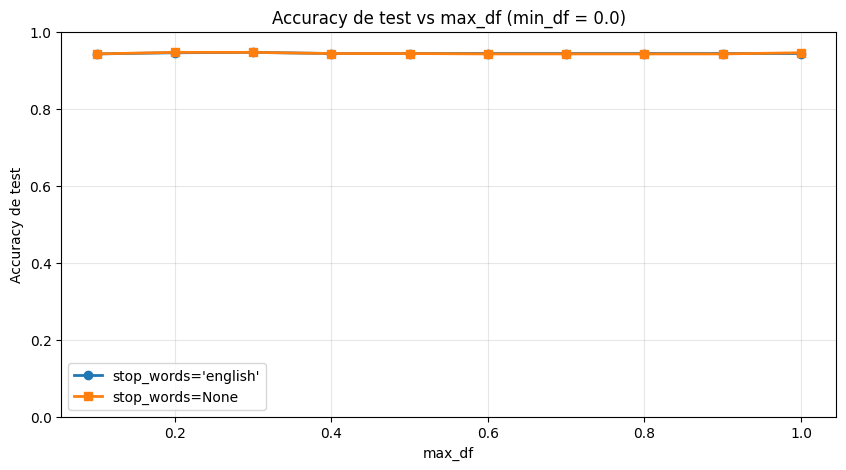


Tabla de resultados (min_df = 0.0):
   max_df  acc_english  acc_none  diferencia
0     0.1        0.942     0.942       0.000
1     0.2        0.945     0.946       0.001
2     0.3        0.946     0.946       0.000
3     0.4        0.943     0.943       0.000
4     0.5        0.943     0.943       0.000
5     0.6        0.943     0.942      -0.001
6     0.7        0.943     0.942      -0.001
7     0.8        0.943     0.942      -0.001
8     0.9        0.943     0.942      -0.001
9     1.0        0.943     0.945       0.002


In [19]:
min_df_fijo = 0.0
max_df_vals = np.linspace(0.1, 1.0, 10)
acc_vs_max_english = []
acc_vs_max_none = []

for max_df_val in max_df_vals:
    # Con stop_words='english'
    vect_english = CountVectorizer(
        max_df=float(max_df_val),
        min_df=min_df_fijo,
        stop_words='english'
    )
    Xtr_english = vect_english.fit_transform(X_train)
    Xte_english = vect_english.transform(X_test)
    clf_english = MultinomialNaiveBayes(alpha=1.0)
    clf_english.fit(Xtr_english, y_train)
    acc_vs_max_english.append(clf_english.score(Xte_english, y_test))

    # Con stop_words=None
    vect_none = CountVectorizer(
        max_df=float(max_df_val),
        min_df=min_df_fijo,
        stop_words=None
    )
    Xtr_none = vect_none.fit_transform(X_train)
    Xte_none = vect_none.transform(X_test)
    clf_none = MultinomialNaiveBayes(alpha=1.0)
    clf_none.fit(Xtr_none, y_train)
    acc_vs_max_none.append(clf_none.score(Xte_none, y_test))

plt.figure(figsize=(10, 5))
plt.plot(max_df_vals, acc_vs_max_english, marker='o', linewidth=2, label="stop_words='english'")
plt.plot(max_df_vals, acc_vs_max_none, marker='s', linewidth=2, label="stop_words=None")
plt.title('Accuracy de test vs max_df (min_df = 0.0)')
plt.xlabel('max_df')
plt.ylabel('Accuracy de test')
plt.legend()
plt.grid(alpha=0.3)
plt.ylim(0, 1)
plt.show()

results_comparison = pd.DataFrame({
    'max_df': max_df_vals,
    'acc_english': acc_vs_max_english,
    'acc_none': acc_vs_max_none
})
results_comparison['diferencia'] = results_comparison['acc_none'] - results_comparison['acc_english']

print('\nTabla de resultados (min_df = 0.0):')
print(results_comparison)

Al comparar el rendimiento del modelo utilizando `stop_words='english'` y `stop_words=None`, se observa que las curvas de accuracy en función de `max_df` son prácticamente idénticas.

Las diferencias en accuracy son del orden de $±0.001$, lo cual es despreciable en relación a la escala del problema. Además, ambas configuraciones presentan el mismo comportamiento general, con un leve máximo en valores intermedios de `max_df` y una ligera disminución en los extremos.

Este resultado indica que la eliminación explícita de stop words no tiene un impacto significativo en el desempeño del modelo. Una posible explicación es que el parámetro `max_df` ya filtra palabras muy frecuentes, cumpliendo un rol similar al de las stop words.

Adicionalmente, en el modelo Multinomial Naive Bayes, las palabras que aparecen en la mayoría de los documentos tienden a no aportar información discriminativa, por lo que su presencia o ausencia tiene poco efecto en la clasificación.

En conjunto, estos resultados sugieren que, en este problema, la eliminación de stop words es en gran medida redundante cuando se utilizan otros mecanismos de filtrado basados en la frecuencia de las palabras.

Dado que la eliminación de stop words no produce mejoras significativas en el desempeño del modelo, su impacto en el pipeline resulta limitado desde el punto de vista del accuracy.

En términos computacionales, eliminar stop words puede reducir levemente el tamaño del vocabulario y, por lo tanto, el costo de entrenamiento y evaluación. Sin embargo, los resultados muestran que la principal reducción en la dimensionalidad se logra mediante los parámetros `min_df` y `max_df`, en particular `min_df`, que tiene un efecto mucho más marcado sobre el número de características.

En consecuencia, aunque el uso de stop words puede aportar una mejora marginal en términos de eficiencia, su influencia es secundaria frente al filtrado basado en frecuencia. Por este motivo, su inclusión no resulta determinante en este problema.



### 3. Accuracy de test vs `min_df` con `max_df = 0.2`

En este experimento se analiza cómo varía el desempeño del modelo al modificar el parámetro `min_df`, manteniendo fijo `max_df = 0.2` y utilizando `stop_words='english'`. Esta elección se basa en los análisis previos, donde se observó que la inclusión o exclusión de stop words no produce diferencias significativas en el rendimiento, por lo que se adopta una configuración consistente para este estudio.

El parámetro `min_df` controla la frecuencia mínima de aparición en términos de documentos: una palabra se conserva en el vocabulario solo si aparece en al menos una fracción determinada de los documentos del corpus. Es decir, no mide cuántas veces aparece dentro de un texto, sino en cuántos documentos distintos aparece al menos una vez.

Para cada valor de `min_df`, se reconstruye el pipeline completo:
- Se define un nuevo `CountVectorizer` con los parámetros correspondientes.
- Se ajusta sobre el conjunto de entrenamiento.
- Se transforman los datos de entrenamiento y test.
- Se entrena un modelo Multinomial Naive Bayes desde cero.
- Se evalúa el accuracy sobre el conjunto de test.

Este procedimiento permite estudiar cómo afecta el filtrado de palabras poco frecuentes al desempeño del modelo.

A diferencia de lo observado con `max_df`, donde el rendimiento era prácticamente constante, aquí se espera una mayor sensibilidad, ya que `min_df` controla directamente la eliminación de términos raros, que en el contexto de artículos científicos pueden corresponder a palabras técnicas relevantes para distinguir entre categorías.


min_df=0.200: sin vocabulario luego del filtrado (se registra NaN).


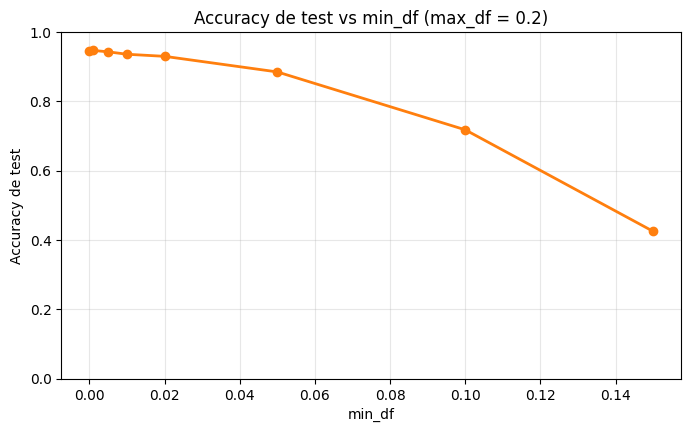


Tabla de resultados (max_df = 0.2):
   min_df  acc_test
0   0.000     0.945
1   0.001     0.947
2   0.005     0.943
3   0.010     0.936
4   0.020     0.930
5   0.050     0.885
6   0.100     0.718
7   0.150     0.425
8   0.200       NaN


In [16]:
max_df_fijo = 0.2
min_df_vals = np.array([0.0, 0.001, 0.005, 0.01, 0.02, 0.05, 0.1, 0.15, 0.2])
acc_vs_min = []

for min_df_val in min_df_vals:
    vect = CountVectorizer(
        max_df=max_df_fijo,
        min_df=float(min_df_val),
        stop_words='english'
    )

    try:
        Xtr = vect.fit_transform(X_train)
        Xte = vect.transform(X_test)

        clf = MultinomialNaiveBayes(alpha=1.0)
        clf.fit(Xtr, y_train)
        acc_vs_min.append(clf.score(Xte, y_test))
    except ValueError as e:
        if 'After pruning, no terms remain' in str(e):
            acc_vs_min.append(np.nan)
            print(f'min_df={min_df_val:.3f}: sin vocabulario luego del filtrado (se registra NaN).')
        else:
            raise

acc_vs_min = np.array(acc_vs_min, dtype=float)
mask_valid = ~np.isnan(acc_vs_min)

plt.figure(figsize=(8, 4.5))
plt.plot(min_df_vals[mask_valid], acc_vs_min[mask_valid], marker='o', linewidth=2, color='tab:orange')
plt.title('Accuracy de test vs min_df (max_df = 0.2)')
plt.xlabel('min_df')
plt.ylabel('Accuracy de test')
plt.grid(alpha=0.3)
plt.ylim(0, 1)
plt.show()

print('\nTabla de resultados (max_df = 0.2):')
print(pd.DataFrame({'min_df': min_df_vals, 'acc_test': acc_vs_min}))

Al analizar la variación del accuracy en función de `min_df`, manteniendo fijo `max_df = 0.2`, se observa una fuerte dependencia del rendimiento respecto a este hiperparámetro.

Para valores bajos de `min_df` (0.0–0.001), el modelo alcanza su mejor desempeño (≈ 0.947), lo que indica que incluir palabras poco frecuentes no perjudica la clasificación e incluso aporta información relevante.

Sin embargo, a medida que aumenta `min_df`, el accuracy disminuye de forma sostenida. Esto se debe a que el criterio de filtrado se vuelve progresivamente más restrictivo, eliminando palabras que, aunque aparezcan en pocos documentos, contienen información discriminativa importante para diferenciar las clases.

Para valores moderados (≈ 0.01–0.02), la caída en el rendimiento ya es significativa, mientras que para valores altos (≥ 0.05), el modelo pierde gran parte de su capacidad predictiva, llegando a accuracies inferiores a 0.7 e incluso cercanas a 0.4.

En el caso extremo (`min_df = 0.2`), el filtrado elimina completamente el vocabulario, lo que impide el entrenamiento del modelo.

Estos resultados muestran que `min_df` es el hiperparámetro más influyente del vectorizador, ya que controla directamente la cantidad de información disponible para el clasificador. A diferencia de `max_df` y `stop_words`, que tienen un impacto marginal, un valor demasiado alto de `min_df` provoca una pérdida severa de información y degrada significativamente el desempeño del modelo.